In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir("/content/drive/MyDrive/NLP Final Project/bertopic_model"))

['topic_embeddings.safetensors', 'config.json', 'topics.json']


In [3]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.5 MB/s eta 0:00:00


In [4]:
import os
from bertopic import BERTopic

os.chdir("/content/drive/MyDrive/NLP Final Project")
topic_model = BERTopic.load("bertopic_model")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2026-03-06 22:11:46,029 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


In [5]:
topic_labels = {
    0: "AI Image Generation & Creative Tools",
    1: "U.S. Federal Politics",
    2: "Clinical Research & Biotech",
    3: "Crypto Trading & Market Tools",
    4: "Startups & Venture Ecosystem",
    5: "Stock Markets & Earnings",
    6: "Regional Media & Press Distribution",
    7: "Indian National Politics",
    8: "Press Release Distribution Services",
    9: "Smartphones & Consumer Devices",
    10: "Public Broadcasting & Arts Media",
    11: "ChatGPT & AI Tools",
    12: "Chinese AI & Tech Competition",
    13: "Semiconductors & GPUs",
    14: "Climate & Renewable Energy",
    15: "Middle East Financial Markets",
    16: "Cybersecurity & Threat Intelligence",
    17: "OpenAI Leadership & Governance",
    18: "AI Copyright & Legal Disputes",
    19: "Developer Tools & Productivity Apps",
    20: "E-Commerce & Conversational AI",
    21: "Music Streaming & Digital Music Industry",
    -1: "Outliers"
}
topic_model.set_topic_labels(topic_labels)

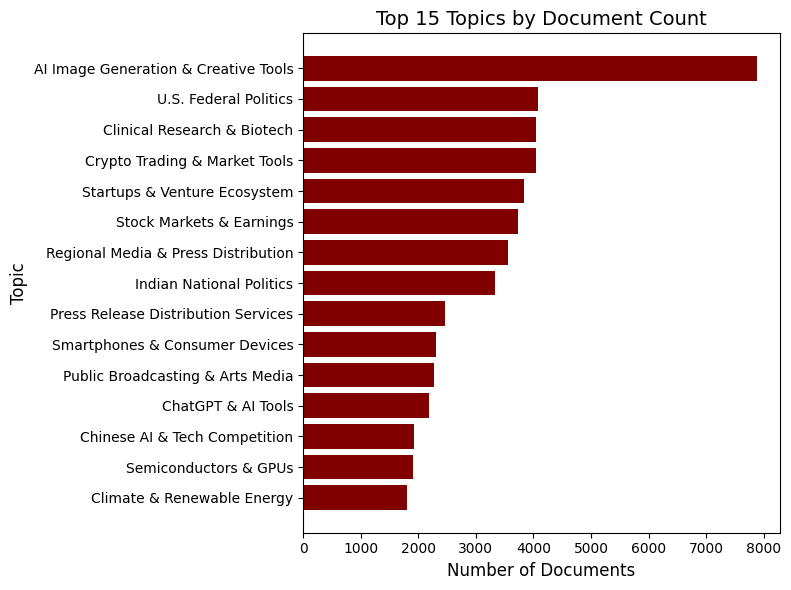

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

uchicago_red = "#800000"

# Get topic counts
topic_info = topic_model.get_topic_info()

# Remove outliers
topic_info = topic_info[topic_info["Topic"] != -1]

# Map custom labels explicitly
topic_info["Custom_Name"] = topic_info["Topic"].map(topic_labels)

# Sort by document count
top20 = topic_info.sort_values("Count", ascending=False).head(15)

# Reverse for horizontal bar ordering (largest on top)
top20 = top20.sort_values("Count", ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top20["Custom_Name"], top20["Count"], color=uchicago_red)

plt.xlabel("Number of Documents", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.title("Top 15 Topics by Document Count", fontsize=14)

plt.tight_layout()
plt.show()

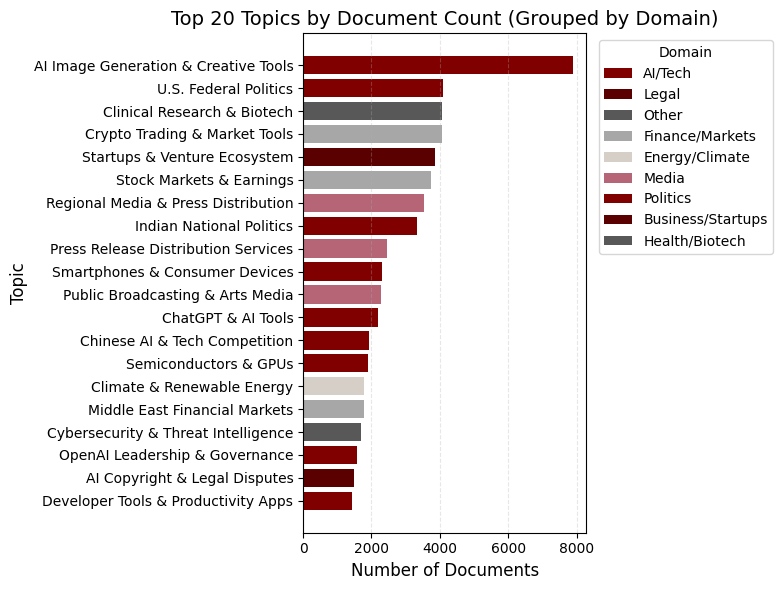

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- UChicago palette ---
uchicago_palette = [
    "#800000",  # UChicago Maroon
    "#5A0000",  # Dark Maroon
    "#585858",  # Dark Gray
    "#A7A7A7",  # Light Gray
    "#D6CFC7",  # Beige
    "#B56576"   # Rose accent
]

# --- Domain grouping ---
domain_map = {
    0: "AI/Tech", 9: "AI/Tech", 11: "AI/Tech", 12: "AI/Tech", 13: "AI/Tech", 17: "AI/Tech", 19: "AI/Tech",
    1: "Politics", 7: "Politics",
    3: "Finance/Markets", 5: "Finance/Markets", 15: "Finance/Markets",
    6: "Media", 8: "Media", 10: "Media",
    2: "Health/Biotech",
    14: "Energy/Climate",
    18: "Legal",
    4: "Business/Startups",
    20: "Retail/E-commerce",
    -1: "Outliers"
}

# --- Build Top 20 table ---
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1].copy()

topic_info["Topic_Name"] = topic_info["Topic"].map(topic_labels).fillna(topic_info["Name"])
topic_info["Domain"] = topic_info["Topic"].map(domain_map).fillna("Other")

top20 = topic_info.sort_values("Count", ascending=False).head(20).copy()
top20 = top20.sort_values("Count", ascending=True)

# --- Assign UChicago colors to domains ---
domains_in_plot = list(pd.unique(top20["Domain"]))
domain_to_color = {
    d: uchicago_palette[i % len(uchicago_palette)]
    for i, d in enumerate(domains_in_plot)
}

bar_colors = top20["Domain"].map(domain_to_color)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.barh(top20["Topic_Name"], top20["Count"], color=bar_colors)

plt.xlabel("Number of Documents", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.title("Top 20 Topics by Document Count (Grouped by Domain)", fontsize=14)

# Legend
handles = [Patch(facecolor=domain_to_color[d], label=d) for d in domains_in_plot]
plt.legend(handles=handles, title="Domain", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
!pip install wordcloud

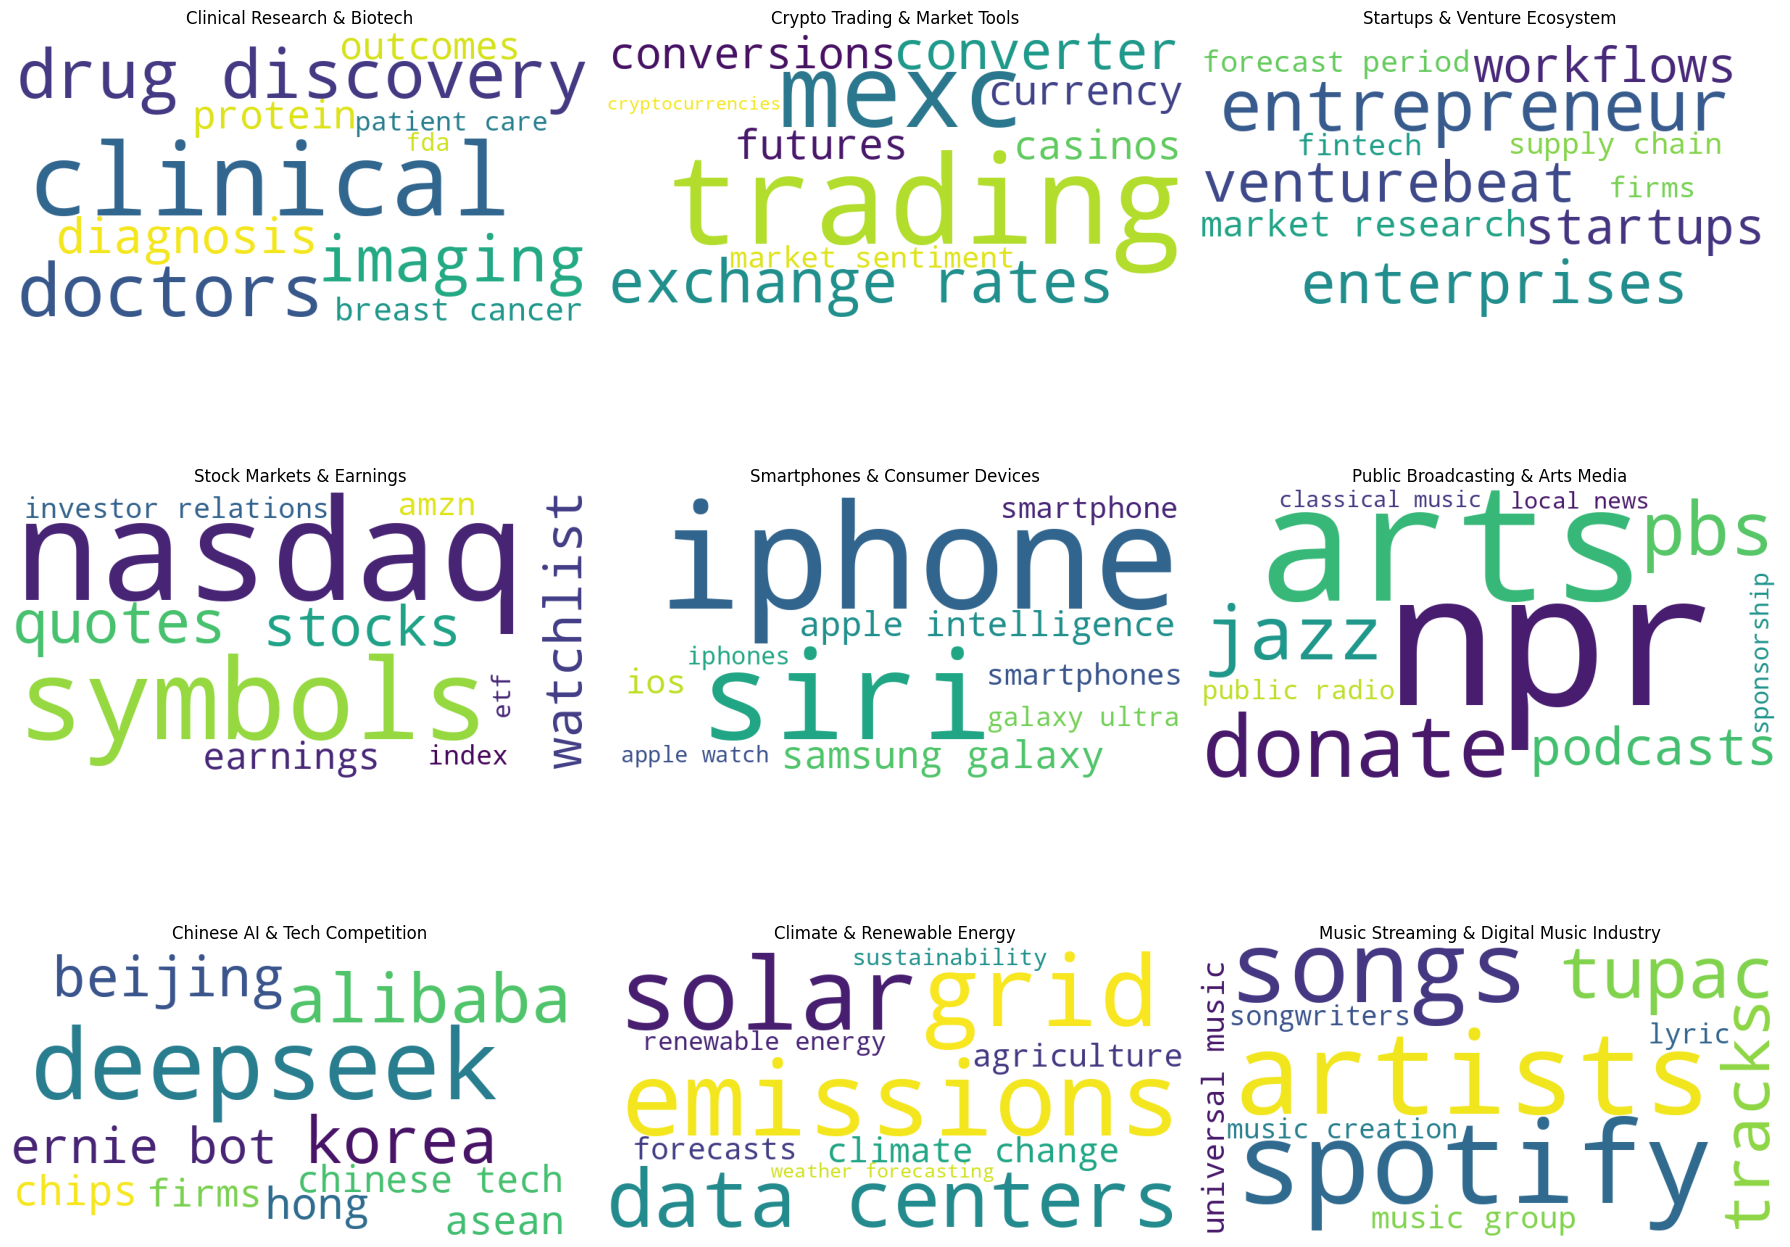

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

selected_topics = [2, 3, 4, 5, 9, 10, 12, 14, 21]
N_WORDS = 80

all_topics = topic_model.get_topics()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, topic_id in enumerate(selected_topics):

    ax = axes[i]

    if topic_id not in all_topics or all_topics[topic_id] is None:
        ax.set_title(f"Topic {topic_id} Not Found")
        ax.axis("off")
        continue

    words_weights = all_topics[topic_id][:N_WORDS]
    freq_dict = dict(words_weights)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=N_WORDS
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc)
    ax.axis("off")

    title = topic_labels.get(topic_id, f"Topic {topic_id}")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
topic_model.visualize_barchart(top_n_topics=20)

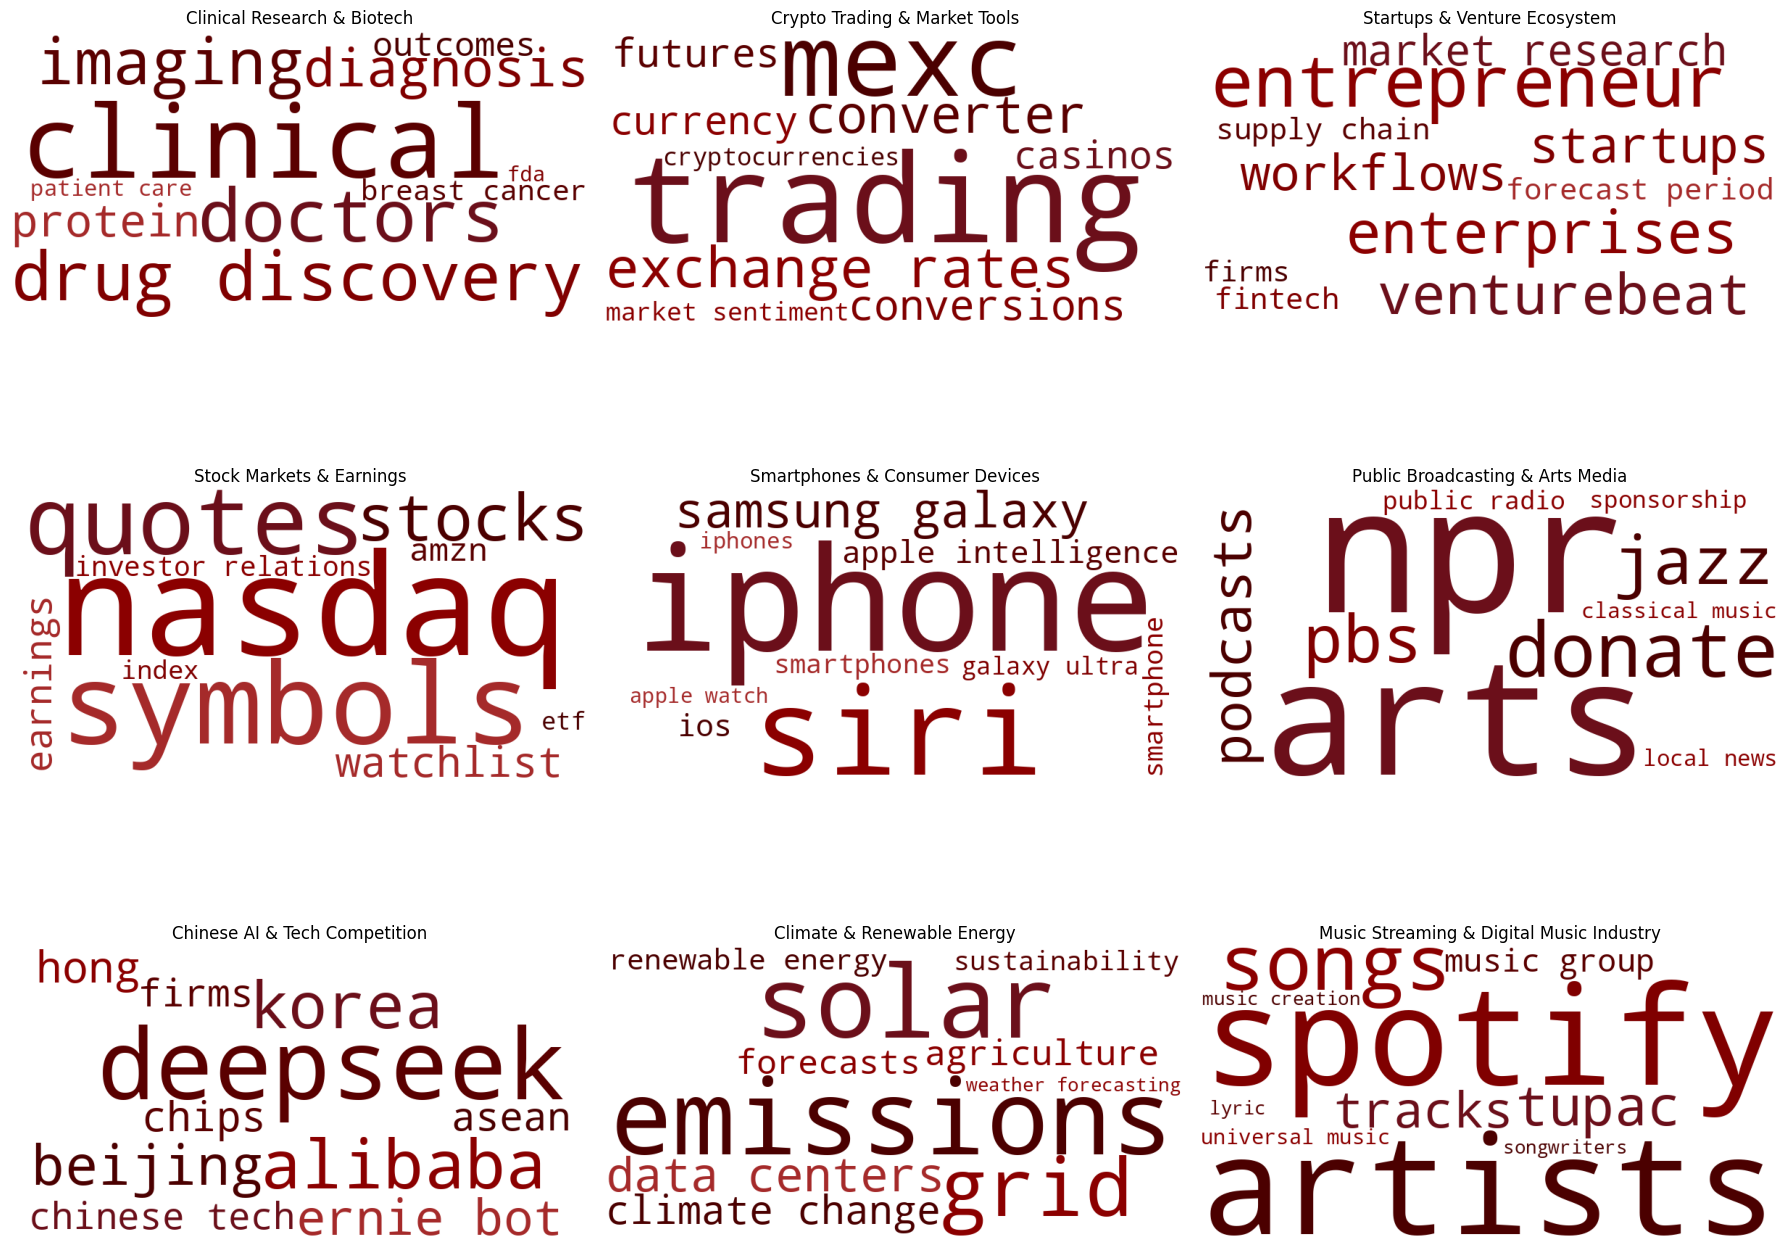

In [21]:
dark_red_palette = [
    "#800000",  # UChicago maroon
    "#5A0000",
    "#6B0F1A",
    "#8B0000",
    "#A52A2A",
    "#4B0000"
]

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

selected_topics = [2, 3, 4, 5, 9, 10, 12, 14, 21]
N_WORDS = 80

all_topics = topic_model.get_topics()

# Dark red palette
dark_red_palette = [
    "#800000",
    "#5A0000",
    "#6B0F1A",
    "#8B0000",
    "#A52A2A",
    "#4B0000"
]

def red_color_func(*args, **kwargs):
    return random.choice(dark_red_palette)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, topic_id in enumerate(selected_topics):

    ax = axes[i]

    if topic_id not in all_topics or all_topics[topic_id] is None:
        ax.set_title(f"Topic {topic_id} Not Found")
        ax.axis("off")
        continue

    words_weights = all_topics[topic_id][:N_WORDS]
    freq_dict = dict(words_weights)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=N_WORDS,
        color_func=red_color_func
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc)
    ax.axis("off")

    title = topic_labels.get(topic_id, f"Topic {topic_id}")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
topic_model.visualize_topics()

In [12]:
for tid in range(22, 29):
    print(tid, topic_model.get_topic(tid))

22 [['seeking alpha', 0.020932149807125152], ['benzinga', 0.02067284393036566], ['crypto', 0.016144402804963636], ['non fungible', 0.013259212848479548], ['good investment', 0.013142694464082125], ['cap', 0.012530725154761706], ['nfts', 0.011638910955573194], ['stocks', 0.010537750672884602], ['pharma', 0.008275928885337085], ['ecommerce', 0.007534345089288654]]
23 [['texas', 0.01565157355844745], ['fcc', 0.011324401500331517], ['mins ago', 0.009997427883669674], ['hill', 0.009370364867700442], ['contests', 0.008210448940793091], ['sports illustrated', 0.00785501269791929], ['austin', 0.007344877095391235], ['weather app', 0.0071643036051058], ['county', 0.007066229912074124], ['cbs news', 0.007019108863609528]]
24 [['salary', 0.259537224697693], ['data scientist', 0.18153382071586718], ['compensation', 0.17930010405255392], ['salaries', 0.10675564290426595], ['resume', 0.05262905462931502], ['yearly', 0.05199979495061551], ['recruiters', 0.04214302218412783], ['dev', 0.031351477109291